__ƯỚC LƯỢNG__

*Khi biết sigma (độ lệch chuẩn của tổng thể)
$$CI = \bar{X} \pm Z_{\alpha/2} \times \frac{\sigma}{\sqrt{n}}


* Khi không biết sigma

$$CI = \bar{X} \pm t_{\alpha/2, n-1} \times \frac{s}{\sqrt{n}}

__Xác định kích thước mẫu cần thiết để ước lượng trung bình quần thể__

$$n = \left( \frac{Z_{\alpha/2} \times \sigma} {E}\right)^2 $$



Trong đó:  
- \( E \): Sai số mong muốn  
- \( Z \): Giá trị Z phụ thuộc vào mức độ tin cậy (ví dụ: 1.96 cho 95%)

__Ước lượng điểm giá trị tỷ lệ__

$$\hat{p} = \frac{x} n $$

Trong đó:  
- \( x \):  số lượng thành viên có đặc điểm cần nghiên cứu
- \( n \): quan the

__Ước lượng khoảng giá trị tỷ lệ__

$$CI = \hat{p} \pm Z_{\alpha/2} \times  \sqrt {\left ( \frac {\hat{p} (1 - \hat{p})} {n}\right)}

__Xác định kích thước mẫu cần thiết đế ước lượng tỷ lệ quần thể__
$$n = \left( \frac{Z_{\alpha/2}^2 \times p(1 - p)} {E^2}\right) $$

Nếu không biết p, chọn p =0.5 đế có kích thước mẫu lớn nhất

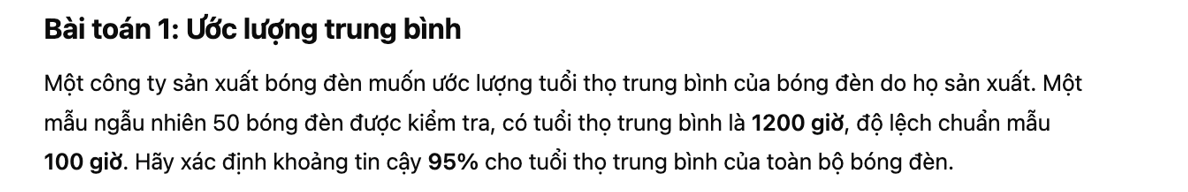

In [4]:
import numpy as np
import math
from scipy import stats
import matplotlib.pyplot as plt
# Xác định khoảng tin cậy nên ta sử dụng công thức tính khoảng tin cậy:
#Ta có

mean = 1200 # Tuổi thọ trung bình
t = stats.t.ppf(1-0.05/2,df=49)
s=100
n = 50

CI = (
    mean - t *s/np.sqrt(n),
    mean + t *s/np.sqrt(n)
)

print(CI)

(np.float64(1171.580314450427), np.float64(1228.419685549573))


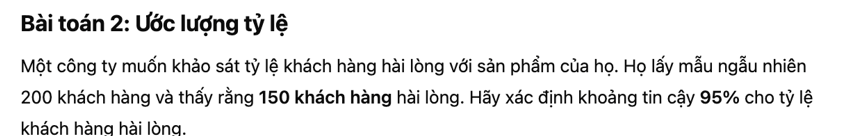

In [5]:
#Theo đề bài ta sử dụng công thức Ước lượng khoảng tỷ lệ
#Ta có
p = 150/200
z = stats.norm.ppf(1- 0.05/2)

CI = (
    p + z * np.sqrt((p * (1 - p)) / 200),
    p - z * np.sqrt((p * (1 - p)) / 200)
)

print(CI)

(np.float64(0.8100113959544414), np.float64(0.6899886040455586))


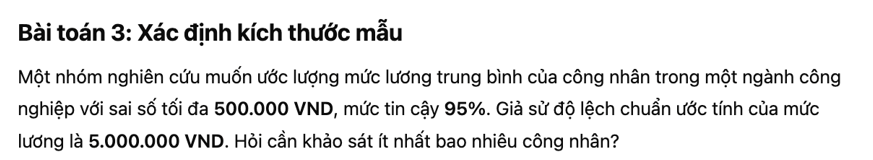

In [6]:
#Theo đề bài ta áp dụng công thức:
E = 500000
z = stats.norm.ppf(1-0.05/2)
sigma = 5000000

n = np.pow((z * sigma) / E,2)
print(n)

384.1458820694126


__Kiểm định__

# Phần 2: Kiểm định

## Tổng hợp công thức: 

### 🧪 Công thức tính trị kiểm định (Test Statistic)

| Tên kiểm định            | Công thức trị kiểm định                                               | Ý nghĩa |
|--------------------------|----------------------------------------------------------------------|--------|
| **Z - Trung bình (biết σ)** | $ z = \frac{\bar{x} - \mu_0}{\sigma / \sqrt{n}} $                    | So sánh khi biết độ lệch chuẩn tổng thể |
| **T - Trung bình (không biết σ)** | $ t = \frac{\bar{x} - \mu_0}{s / \sqrt{n}} $ | Khi không biết σ, dùng độ lệch chuẩn mẫu |
| **Z - Tỷ lệ**               | $ z = \frac{\hat{p} - p_0}{\sqrt{p_0(1 - p_0)/n}} $                    | Kiểm định tỷ lệ | 

### 📊 Cách tính p-value theo loại kiểm định

| Loại kiểm định | Dạng kiểm định | Công thức tính p-value (Python)                                   |
|----------------|----------------|---------------------------------------------------------------------|
| **Z (biết σ)** | 2 phía         | `2 * (1 - norm.cdf(abs(z)))`                                       |
|                | Phía trái      | `norm.cdf(z)`                                                      |
|                | Phía phải      | `1 - norm.cdf(z)`                                                  |
| **T (không biết σ)** | 2 phía         | `2 * (1 - t.cdf(abs(t), df=n-1))`                            |
|                | Phía trái      | `t.cdf(t, df=n-1)`                                                 |
|                | Phía phải      | `1 - t.cdf(t, df=n-1)`                                             |

### 🚫 Miền bác bỏ (Vùng từ chối H₀)

| Loại kiểm định      | Dạng kiểm định | Miền bác bỏ (với mức ý nghĩa α)                     |
|---------------------|----------------|-----------------------------------------------------|
| **Z (biết σ)**      | 2 phía         | $|z| > z_{\alpha/2}$                              |
|                     | Phía trái      | $z < -z_{\alpha}$                                 |
|                     | Phía phải      | $z > z_{\alpha}$                                  |
| **T (không biết σ)**| 2 phía         | $|t| > t_{\alpha/2, n-1}$                         |
|                     | Phía trái      | $t < -t_{\alpha, n-1}$                            |
|                     | Phía phải      | $t > t_{\alpha, n-1}$                             |

### 🎯 Công thức tính trị tới hạn (Critical Value)

| Loại kiểm định      | Dạng kiểm định | Công thức trị tới hạn (Python)                                | Ý nghĩa |
|---------------------|----------------|----------------------------------------------------------------|---------|
| **Z (biết σ)**      | 2 phía         | `z_crit = norm.ppf(1 - α/2)`                                   | $z_{\alpha/2} $ |
|                     | Phía trái      | `z_crit = norm.ppf(α)`                                         | $ z_{\alpha} $ (âm) |
|                     | Phía phải      | `z_crit = norm.ppf(1 - α)`                                     | $ z_{\alpha} $ |
| **T (không biết σ)**| 2 phía         | `t_crit = t.ppf(1 - α/2, df=n-1)`                              | $ t_{\alpha/2, n-1} $ |
|                     | Phía trái      | `t_crit = t.ppf(α, df=n-1)`                                    | $ t_{\alpha, n-1} $ (âm) |
|                     | Phía phải      | `t_crit = t.ppf(1 - α, df=n-1)`                                | $ t_{\alpha, n-1} $ |

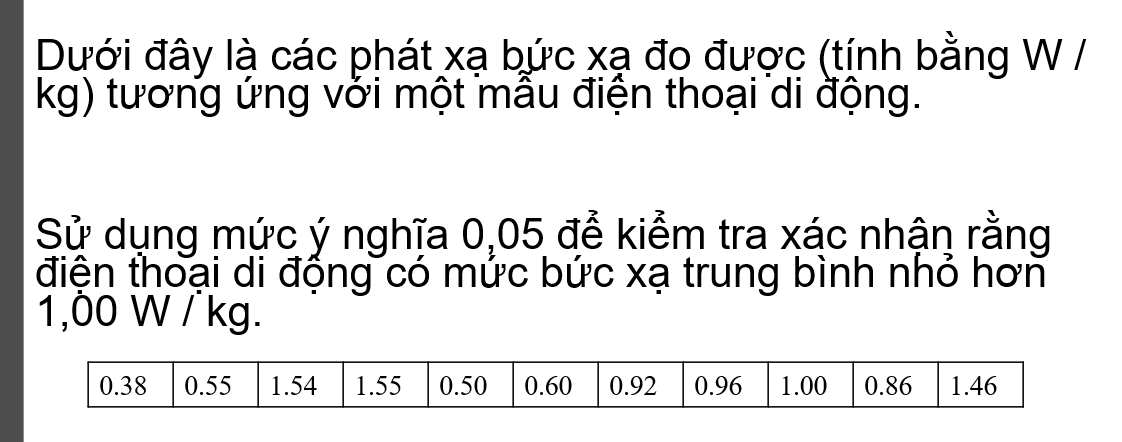

In [7]:
mean = 0.938
s = 0.423
a =0.05
n = 11
trikiemdinh = trikiemdinh = ((mean - 1) / (s / np.sqrt(n))).round(4)
print(trikiemdinh)
mienbacbo = stats.t.ppf(a, n-1).round(4)
print(mienbacbo)

-0.4861
-1.8125


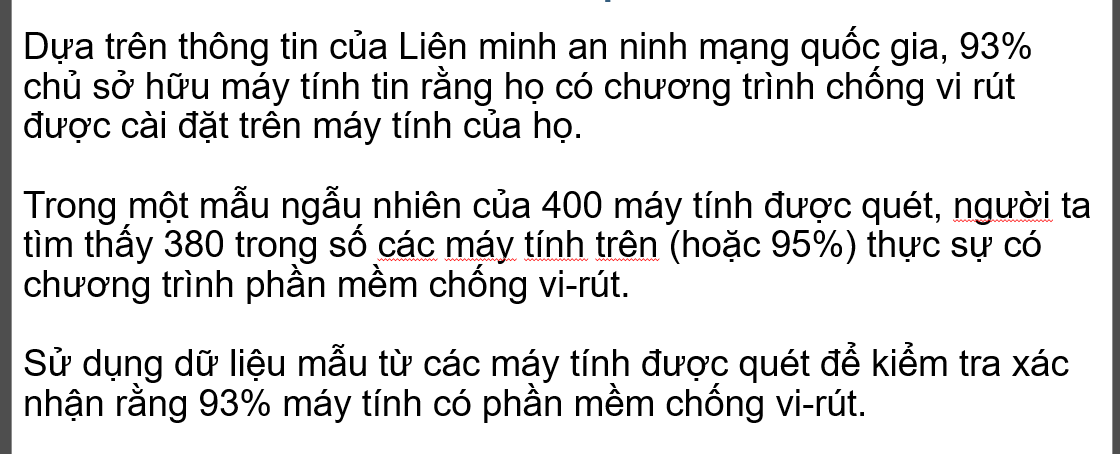

In [19]:
p0 = 0.93
n = 400
q = 1 - p0
p = 380/400

z = (p - p0)/ (np.sqrt((p0 * q) /n))
print(z)

p_value = 2 * (1 - stats.t.cdf(abs(1.57),df=n-1))
print(p_value)

1.567723603339234
0.11720776102052355


## 2 Tailed ##

# Giá trị tới hạn:
t_crit = stats.t.ppf(1 - alpha/2, df=n-1)

# hoặc với phân phối chuẩn:
z_crit = stats.norm.ppf(1 - alpha/2)

# p-value:
p_value = 2 * stats.t.sf(abs(t_stat), df=n-1)


## right tailed ##

# Giá trị tới hạn:
t_crit = stats.t.ppf(1 - alpha, df=n-1)

# p-value:
p_value = stats.t.sf(t_stat, df=n-1)


# Left tailed #

# Giá trị tới hạn:
t_crit = stats.t.ppf(alpha, df=n-1)

# p-value:
p_value = stats.t.cdf(t_stat, df=n-1)
